# How Fresh Are Your Blueberries? — Article Figures

Companion notebook for the blog post draft. Follows the post's own section order;
every figure the post uses is generated here, inline, from the current codebase —
this notebook is the reproducible source for all of them.


In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
import time
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import wasserstein_distance
from matplotlib.lines import Line2D

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src" / "blueberries_voi").is_dir():
    REPO_ROOT = REPO_ROOT.parent

os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")
_wheel_dir = REPO_ROOT / "dist" / "wheel"
if _wheel_dir.is_dir():
    os.environ["BLUEBERRIES_VOI_WHEEL"] = str(_wheel_dir)

FIG_DIR = REPO_ROOT / "notebooks" / "outputs" / "article_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, RED, PURPLE, GREEN = "#4C72B0", "#DD8452", "#C44E52", "#8172B3", "#55A868"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

print("repo:", REPO_ROOT)


repo: /home/oliver/blog/blueberries-voi


## The model

### Freshness and spoilage — the Gamma process

$$f(t+1) = \max\big(f(t) - \Delta_t,\ 0\big), \qquad \Delta_t \sim \mathrm{Gamma}\big(k \cdot \phi(T_t),\ \theta\big), \qquad \phi(T) = Q_{10}^{\,(T - T_{\text{ref}})/10}$$

Ported directly from `web/src/charts/physicsTeaching.ts` (`gammaFreshnessEnvelope`,
`gammaDecrementStats`, `storeTempFactor`) — the same math driving Blueberry Studio's
live Physics tab. Verified against the running Studio UI: at defaults
(`eta_ref=14`, `Q10=2`, `T_ref=0°C`, `T_store=4°C`) this reproduces the exact displayed
`γ(2.64, 0.0357)`, expiry day 11.

Three store temperatures shown together to make the $Q_{10}$ effect visible in one
figure: mean $\pm$ 1$\sigma$ envelope (deterministic, uncensored) plus 3 sampled
realizations per temperature (thin lines, same color) showing what the discrete
day-by-day process actually looks like.

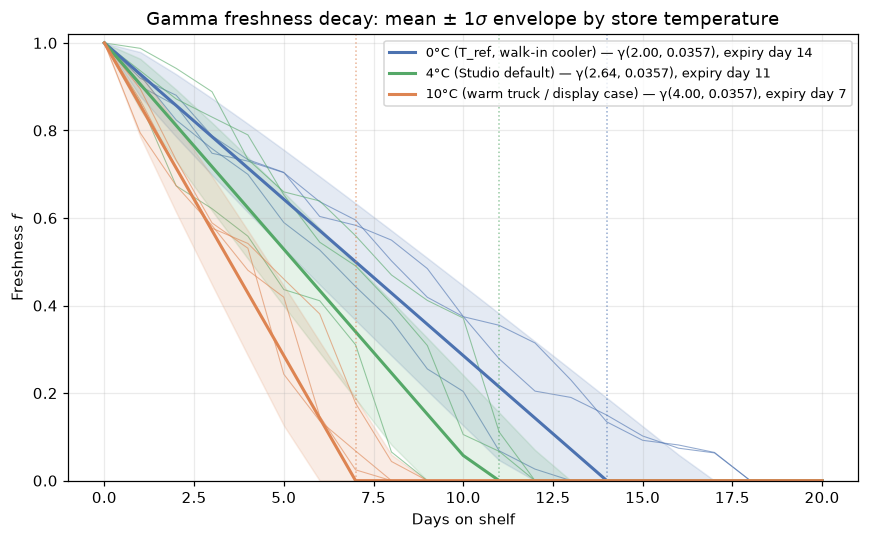

In [2]:
GAMMA_SHAPE = 2.0
ETA_REF = 14.0
Q10 = 2.0
T_REF_C = 0.0

def store_temp_factor(t_store_c):
    return max(1.01, Q10) ** ((t_store_c - T_REF_C) / 10)

def gamma_decrement_stats(t_store_c):
    theta = 1.0 / (GAMMA_SHAPE * ETA_REF)
    phi = store_temp_factor(t_store_c)
    shape = GAMMA_SHAPE * phi
    return shape, theta, phi, shape * theta

def envelope(t_store_c, start_f=1.0, days_to_plot=20):
    shape, theta, phi, mean_delta = gamma_decrement_stats(t_store_c)
    spoil_day = int(np.ceil(start_f / mean_delta))
    days = np.arange(0, days_to_plot + 1)
    mean = start_f - days * mean_delta
    std = np.where(days == 0, 0.0, theta * np.sqrt(days * shape))
    lower = np.clip(mean - std, 0, 1)
    upper = np.clip(mean + std, 0, 1)
    return days, np.clip(mean, 0, None), lower, upper, shape, theta, spoil_day

def realization(t_store_c, rng, start_f=1.0, max_days=60):
    shape, theta, _phi, _mean_delta = gamma_decrement_stats(t_store_c)
    f = start_f
    days, fs = [0], [f]
    for day in range(1, max_days + 1):
        f = max(0.0, f - rng.gamma(shape, theta))
        days.append(day)
        fs.append(f)
        if f <= 0.0:
            break
    return np.array(days), np.array(fs)

rng = np.random.default_rng(42)
N_REALIZATIONS = 3

fig, ax = plt.subplots(figsize=(8, 5))
temps = [(0, BLUE, "0°C (T_ref, walk-in cooler)"),
         (4, GREEN, "4°C (Studio default)"),
         (10, ORANGE, "10°C (warm truck / display case)")]

for t_store, color, label in temps:
    days, mean, lower, upper, shape, theta, spoil_day = envelope(t_store)
    ax.fill_between(days, lower, upper, color=color, alpha=0.15)
    for _ in range(N_REALIZATIONS):
        r_days, r_fs = realization(t_store, rng)
        ax.plot(r_days, r_fs, color=color, linewidth=0.7, alpha=0.6, zorder=1)
    ax.plot(days, mean, color=color, linewidth=2, zorder=2,
            label=f"{label} — γ({shape:.2f}, {theta:.4f}), expiry day {spoil_day}")
    ax.axvline(spoil_day, color=color, linestyle=":", linewidth=1, alpha=0.6)

ax.set_xlabel("Days on shelf")
ax.set_ylabel("Freshness $f$")
ax.set_ylim(0, 1.02)
ax.set_title(r"Gamma freshness decay: mean $\pm$ 1$\sigma$ envelope by store temperature")
ax.legend(fontsize=8.5, loc="upper right")
fig.tight_layout()
fig.savefig(FIG_DIR / "gamma_process.png", dpi=150)
plt.show()


### Delivery conditions — cold-chain calibration overlay

Runs the release Rust diagnostic (`crates/voi_core/examples/t163_phase1_realism_diag.rs`)
fresh and plots the production arrival-freshness distribution (`abdella_mix` corridor
mixture) against the target band and the industry-anchor reference line, exactly as
built in `notebooks/t163_phase1_freshness_realism.ipynb` §11.3.

**Note:** this shells out to `cargo run --release --example ...`, ~1.5–2 minutes
(mostly Rust compile if the example binary isn't already built).

t163_phase1_realism_diag: 32.3s


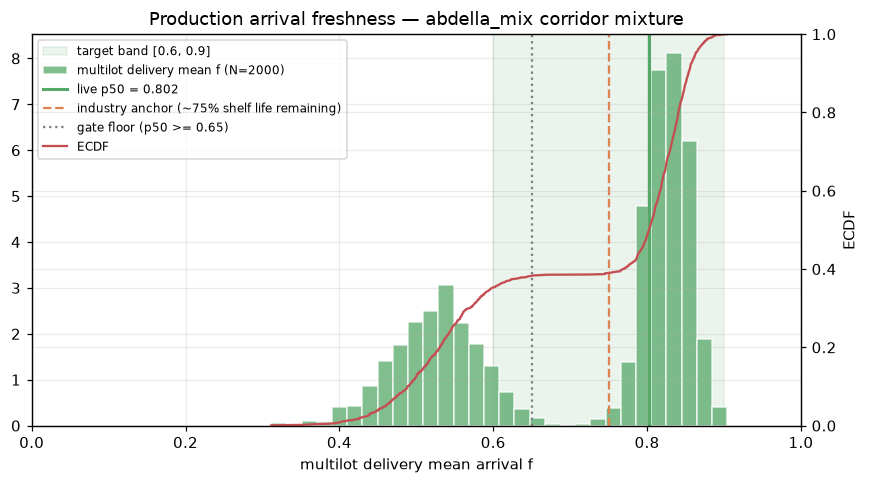

n=2000  mean=0.710  sd=0.153
p10=0.489  p50=0.802  p90=0.854
pct in [0.6,0.9] = 64.7%   pct < 0.5 = 12.5%


In [3]:
def cargo_example(name: str) -> str:
    cmd = ["cargo", "run", "-p", "voi_core", "--release", "--example", name]
    t0 = time.perf_counter()
    proc = subprocess.run(cmd, cwd=REPO_ROOT, capture_output=True, text=True)
    elapsed = time.perf_counter() - t0
    if proc.returncode != 0:
        print(proc.stdout[-4000:])
        print(proc.stderr[-4000:])
        raise RuntimeError(f"{name} failed (exit {proc.returncode})")
    print(f"{name}: {elapsed:.1f}s")
    return proc.stdout

diag_out = cargo_example("t163_phase1_realism_diag")
diag = json.loads(diag_out)
prod_truth = diag["final_production_default"]
samples = np.array(prod_truth["samples"])
band = (0.6, 0.9)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axvspan(*band, color=GREEN, alpha=0.12, label="target band [0.6, 0.9]")
ax.hist(samples, bins=30, density=True, color=GREEN, alpha=0.75, edgecolor="white",
        label=f"multilot delivery mean f (N={len(samples)})")
sorted_s = np.sort(samples)
cdf_y = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
ax2 = ax.twinx()
ax2.plot(sorted_s, cdf_y, color=RED, lw=1.5, label="ECDF")
ax2.set_ylabel("ECDF")
ax2.set_ylim(0, 1)
ax.axvline(prod_truth["p50"], color=GREEN, lw=2, label=f"live p50 = {prod_truth['p50']:.3f}")
ax.axvline(0.75, color=ORANGE, ls="--", lw=1.5, label="industry anchor (~75% shelf life remaining)")
ax.axvline(0.65, color="gray", ls=":", lw=1.5, label="gate floor (p50 >= 0.65)")
ax.set_xlim(0, 1)
ax.set_xlabel("multilot delivery mean arrival f")
ax.set_title(f"Production arrival freshness — {prod_truth['corridor']} corridor mixture")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "cold_chain_calibration.png", dpi=150)
plt.show()

print(f"n={prod_truth['n']}  mean={prod_truth['mean']:.3f}  sd={prod_truth['sd']:.3f}")
print(f"p10={prod_truth['p10']:.3f}  p50={prod_truth['p50']:.3f}  p90={prod_truth['p90']:.3f}")
print(f"pct in [0.6,0.9] = {prod_truth['pct_60_90']:.1f}%   pct < 0.5 = {prod_truth['pct_below_0_5']:.1f}%")


### Demand model — calendar validation (Plot G)

Full FreshRetailNet-50K fitting pipeline lived in `notebooks/15_demand_model_validation.ipynb`
(now archived — deleted from the working tree during notebook cleanup; recoverable via
`git show HEAD:notebooks/15_demand_model_validation.ipynb`). Re-running it here would
re-trigger a fresh dataset download (`.data/freshnet/` isn't cached in this environment),
so this cell just displays the figure already exported from that pipeline rather than
re-deriving it.

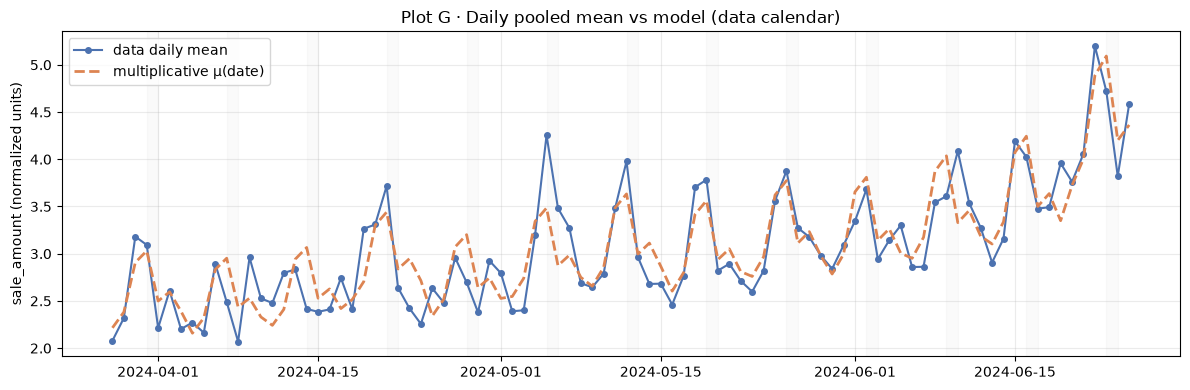

In [4]:
from IPython.display import Image, display
display(Image(filename=str(REPO_ROOT / "figures" / "demand" / "plot_g_daily_mean_vs_model.png")))


## The controller

**Note on which controller these figures use:** `channel_joint.run_seed_channel_joint`
(the pipeline behind every closed-loop chart below) hardcodes `policy="damped_sw"`
via `_damped_sw_act_kw` — regardless of which alpha table entry is loaded. Every figure
in this notebook is `damped_sw`, matching the post's existing controller formula
$q = \mathrm{caseRound}(\rho \cdot \max(0,\ F^{-1}(\alpha) - \tilde I))$ — no rewrite of that
paragraph needed. (`sla_pb`/`sla_mc` were explored separately; `sla_mc` showed a real
MC-convergence instability and was dropped from consideration for this post.)

**Note on `L` (lot-slot wire dimension):** figures below were regenerated at `L=50`
(previously `L=3`). `belief_flat_from_unit_bank` (`crates/voi_core/src/belief_flat.rs`)
exports only the newest `L` lot segments to the belief wire — GSIN populates far more
distinct segments per delivery than UPC does for the same physical shipment (GSIN
pushes each sub-lot as its own segment; UPC merges a whole delivery into one mixture
cohort), so a small `L` truncated GSIN's *oldest* live inventory far more often than
UPC's. That produced a spurious GSIN-looks-worse-than-UPC signal in both the freshness
$W_1$ metric and a signed-bias check (GSIN's belief skewed systematically "fresher than
truth"): missing the stale tail shifts the reported distribution younger. A benchmark
across `L=3,10,20,30` under both `damped_sw` and `sla_pb` found no meaningful runtime
cost difference between `L=10/20/30` (all comfortably inside the 500ms/1000ms autopilot
budgets) — `sla_pb` tail latency was actually *worse* at `L=3` than at any larger `L`.
`DEFAULT_L_DIM` is now `50` in `crates/voi_core/src/params.rs` (Studio's real default,
previously `10` — the `L=3` used throughout this notebook's earlier runs came from a
notebook/experiment convenience override in `profit_session_config`, not from Studio
itself), and `profit_session_config`'s explicit `"L": 3` override has been raised to
match. Rebuilt: `cargo build --release`, `maturin develop --release`, and the Studio
WASM bundle (`scripts/build-wasm.sh`) all reflect `L=50` as of this run.

## Results

### Belief accuracy vs. profit — monotonic ladder

Two separate charts (independent y-axes, since W1 error and profit ratio live on very
different scales), both relative to the "Books only" baseline, 95% CI (t-distribution,
n=8 seeds).

**Methodology note — why two different simulation modes per rung:**
Running the real closed-loop controller per rung (`session.act()`) confounds filter
accuracy with the controller: a better-informed rung orders differently, which changes
its *actual* physical trajectory, so rungs stop being compared against a shared shelf
history. `notebooks/17_prelim_channel_ladder.ipynb` Part 1 avoids this via a **replay**
design — one truth trajectory per seed (fixed exogenous order schedule), replayed
through each rung's observation mask. We reproduce that design here (Tier: paired by
seed, not by exact episode) for the belief-accuracy numbers, while keeping the
profit numbers on the real closed loop (profit is inherently a closed-loop-only
concept — the controller must actually act to have a P&L).

In [5]:
SEEDS = (42, 7, 101, 2024, 13, 99, 256, 777)
N_BURN, N_SCORE = 2, 30
RHO = 0.8

LADDER = [
    ("Books only", {"code_type": "upc", "scan_waste": False, "delivery_history": "none"}),
    ("Scan waste on", {"code_type": "upc", "scan_waste": True, "delivery_history": "none"}),
    ("Pack date", {"code_type": "upc", "scan_waste": True, "delivery_history": "pack_date"}),
    ("GSIN", {"code_type": "gsin", "scan_waste": True, "delivery_history": "pack_date"}),
    ("Temp history", {"code_type": "gsin", "scan_waste": True, "delivery_history": "temperature_history"}),
]
LADDER_ORDER = [label for label, _ in LADDER]

def _process_seed_ladder(seed):
    os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")
    from blueberries_voi.experiments.channel_joint import run_seed_channel_joint
    from blueberries_voi.experiments.voi_profit import _damped_sw_act_kw, profit_session_config
    from blueberries_voi.experiments.belief_accuracy import day_w1_error
    from blueberries_voi.filter.types import ObsChannels
    from blueberries_voi.sim.alpha_tune import require_tuned_alpha_table
    from blueberries_voi.simulator import EngineSession

    alpha = float(require_tuned_alpha_table(REPO_ROOT / "experiments" / "tuned_alpha.json")["sw"])
    baseline_ch = ObsChannels(**LADDER[0][1])

    session = EngineSession()
    cfg = profit_session_config(n_rollout_paths=0)
    session.init(cfg, seed=seed)
    session.set_obs_channels(baseline_ch)
    act_kw = _damped_sw_act_kw(alpha, RHO, n_rollout_paths=0)
    orders = []
    for _ in range(N_BURN + N_SCORE):
        delta = session.act(**act_kw)
        orders.append(int(delta["day"]["order_qty"]))

    rows = []
    for label, ch_kw in LADDER:
        ch = ObsChannels(**ch_kw)
        rsession = EngineSession()
        rsession.init(cfg, seed=seed)
        rsession.set_obs_channels(ch)
        w1s = []
        for day_idx, q in enumerate(orders):
            d = rsession.step(q)
            if day_idx >= N_BURN:
                w1 = day_w1_error(d)
                if w1 is not None:
                    w1s.append(w1)
        w1_mean = sum(w1s) / len(w1s) if w1s else float("nan")
        profit_row = run_seed_channel_joint(seed, ch, n_burn=N_BURN, n_score=N_SCORE,
                                             controller_alpha=alpha, controller_rho=RHO)
        rows.append({"seed": seed, "rung": label, "profit": profit_row["profit"],
                     "freshness_w1_replay": w1_mean})
    return rows

t0 = time.perf_counter()
ladder_rows = []
with ProcessPoolExecutor(max_workers=8) as ex:
    futs = {ex.submit(_process_seed_ladder, s): s for s in SEEDS}
    for fut in as_completed(futs):
        ladder_rows.extend(fut.result())
        print(f"seed {futs[fut]} done ({time.perf_counter()-t0:.1f}s elapsed)")

ladder_df = pd.DataFrame(ladder_rows)
print(f"total elapsed: {time.perf_counter()-t0:.1f}s")
ladder_df.to_csv(FIG_DIR / "ladder_replay_w1_profit.csv", index=False)
ladder_df.pivot_table(index="seed", columns="rung", values="freshness_w1_replay")[LADDER_ORDER]


seed 99 done (49.5s elapsed)


seed 777 done (50.0s elapsed)


seed 7 done (54.2s elapsed)


seed 13 done (56.7s elapsed)


seed 2024 done (57.7s elapsed)


seed 101 done (58.4s elapsed)


seed 256 done (59.1s elapsed)


seed 42 done (60.5s elapsed)
total elapsed: 60.6s


rung,Books only,Scan waste on,Pack date,GSIN,Temp history
seed,,,,,
7,0.131026,0.137333,0.081182,0.052600,0.045326
13,0.140350,0.128500,0.058673,0.054892,0.050152
42,0.144300,0.141987,0.121776,0.142382,0.043991
99,0.146269,0.174121,0.067690,0.053505,0.045310
101,0.140574,0.137571,0.074751,0.049018,0.045134
256,0.158722,0.155350,0.060840,0.058033,0.047520
777,0.160568,0.151738,0.066426,0.048515,0.044604
2024,0.150270,0.145620,0.071325,0.051294,0.045721


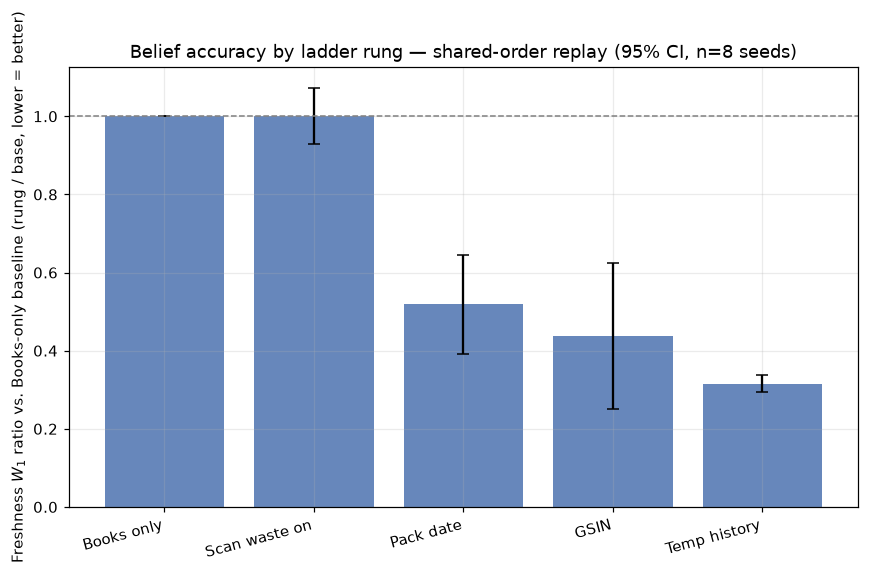

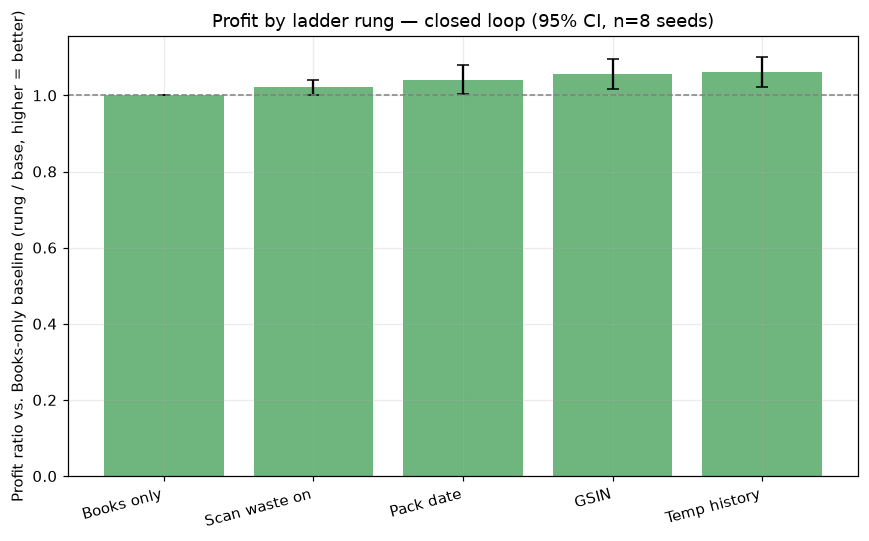

,belief_ratio_mean,belief_ratio_ci95,profit_ratio_mean,profit_ratio_ci95
rung,,,,
Books only,1.000000,0.000000,1.000000,0.000000
Scan waste on,1.001193,0.071247,1.021219,0.020261
Pack date,0.518466,0.126657,1.041011,0.038554
GSIN,0.437859,0.187164,1.055056,0.039478
Temp history,0.315051,0.021570,1.060663,0.039801


In [6]:
piv_profit = ladder_df.pivot_table(index="seed", columns="rung", values="profit")[LADDER_ORDER]
piv_w1 = ladder_df.pivot_table(index="seed", columns="rung", values="freshness_w1_replay")[LADDER_ORDER]

profit_ratio = piv_profit.div(piv_profit["Books only"], axis=0)   # rung/base, higher = better
belief_ratio = piv_w1.div(piv_w1["Books only"], axis=0)           # rung/base, lower = better (raw W1)

n = len(piv_profit)
tcrit = stats.t.ppf(0.975, df=n - 1)

def mean_ci(frame):
    m = frame.mean()
    sem = frame.std(ddof=1) / np.sqrt(n)
    return m, tcrit * sem

profit_mean, profit_ci = mean_ci(profit_ratio)
belief_mean, belief_ci = mean_ci(belief_ratio)

def bar_chart(mean, ci, color, ylabel, title, out_name):
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(LADDER_ORDER))
    ax.bar(x, mean[LADDER_ORDER], yerr=ci[LADDER_ORDER], capsize=4, color=color, alpha=0.85)
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(LADDER_ORDER, rotation=15, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(FIG_DIR / out_name, dpi=150)
    plt.show()

bar_chart(belief_mean, belief_ci, BLUE,
          "Freshness $W_1$ ratio vs. Books-only baseline (rung / base, lower = better)",
          "Belief accuracy by ladder rung — shared-order replay (95% CI, n=8 seeds)",
          "ladder_belief_w1_replay.png")

bar_chart(profit_mean, profit_ci, GREEN,
          "Profit ratio vs. Books-only baseline (rung / base, higher = better)",
          "Profit by ladder rung — closed loop (95% CI, n=8 seeds)",
          "ladder_profit_ratio.png")

pd.DataFrame({"belief_ratio_mean": belief_mean[LADDER_ORDER], "belief_ratio_ci95": belief_ci[LADDER_ORDER],
              "profit_ratio_mean": profit_mean[LADDER_ORDER], "profit_ratio_ci95": profit_ci[LADDER_ORDER]})


### Belief accuracy vs. profit — full 12-cell factorial

Same ratio methodology, but over the full code-type × waste-scan × delivery-history
factorial (`channel_joint.all_obs_channels_product()`, 12 cells) rather than just the
5-rung monotonic path — closed loop throughout (this one intentionally isn't
replay-corrected; it's asking a different question, whether *any* combination of
channels predicts profit, not just the ordered ladder). Legend grammar matches
`figures/channel_joint/profit_vs_mae_dist.png`: color = waste scan, marker = delivery
history, size = code type.

In [7]:
def _process_seed_factorial(seed):
    os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")
    from blueberries_voi.experiments.channel_joint import all_obs_channels_product, run_seed_channel_joint
    rows = []
    for ch in all_obs_channels_product():
        rows.append(run_seed_channel_joint(seed, ch, n_burn=N_BURN, n_score=N_SCORE))
    return rows

t0 = time.perf_counter()
factorial_rows = []
with ProcessPoolExecutor(max_workers=8) as ex:
    futs = {ex.submit(_process_seed_factorial, s): s for s in SEEDS}
    for fut in as_completed(futs):
        factorial_rows.extend(fut.result())
        print(f"seed {futs[fut]} done ({time.perf_counter()-t0:.1f}s elapsed)")

factorial_df = pd.DataFrame(factorial_rows)
factorial_df["combo"] = factorial_df["code_type"] + "|" + factorial_df["waste"] + "|" + factorial_df["delivery"]
factorial_df.to_csv(FIG_DIR / "factorial_w1_profit.csv", index=False)
print(f"total elapsed: {time.perf_counter()-t0:.1f}s, rows: {len(factorial_df)}")


seed 7 done (49.1s elapsed)


seed 99 done (51.2s elapsed)


seed 777 done (52.6s elapsed)


seed 101 done (53.1s elapsed)


seed 2024 done (54.4s elapsed)


seed 13 done (54.6s elapsed)


seed 42 done (55.8s elapsed)


seed 256 done (56.9s elapsed)
total elapsed: 57.0s, rows: 96


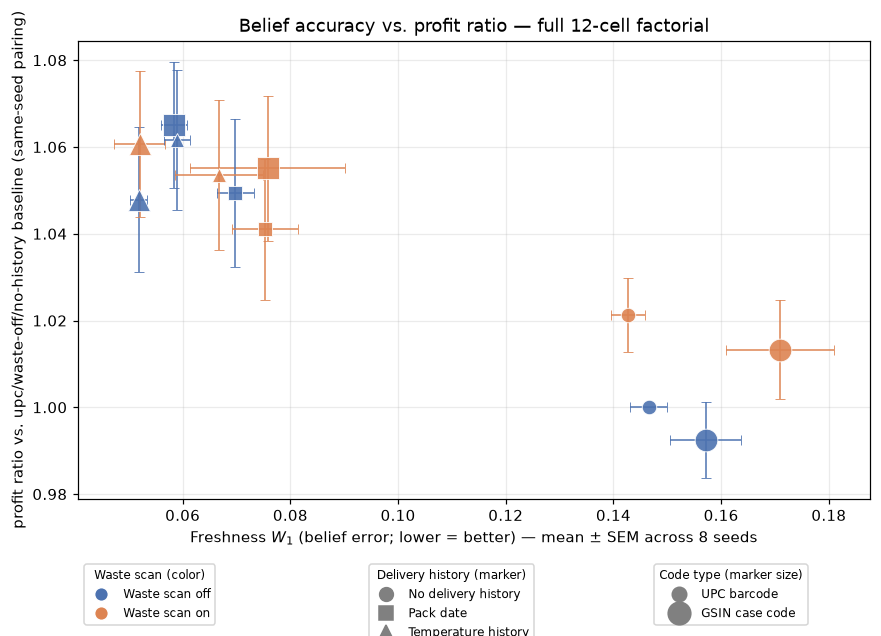

In [8]:
baseline_key = "upc|off|none"
piv_fp = factorial_df.pivot_table(index="seed", columns="combo", values="profit")
f_ratio = piv_fp.div(piv_fp[baseline_key], axis=0)
f_y_mean, f_y_sem = f_ratio.mean(), f_ratio.std(ddof=1) / np.sqrt(len(f_ratio))

piv_fw1 = factorial_df.pivot_table(index="seed", columns="combo", values="freshness_w1")
f_x_mean, f_x_sem = piv_fw1.mean(), piv_fw1.std(ddof=1) / np.sqrt(len(piv_fw1))

combos = factorial_df[["combo", "code_type", "waste", "delivery"]].drop_duplicates().set_index("combo")
waste_color = {"off": BLUE, "on": ORANGE}
delivery_marker = {"none": "o", "pack_date": "s", "temperature_history": "^"}
code_size = {"upc": 90, "gsin": 220}

fig, ax = plt.subplots(figsize=(9, 6.5))
for combo in f_y_mean.index:
    row = combos.loc[combo]
    ax.errorbar(f_x_mean[combo], f_y_mean[combo], xerr=f_x_sem[combo], yerr=f_y_sem[combo],
                fmt=delivery_marker[row["delivery"]], color=waste_color[row["waste"]],
                markersize=np.sqrt(code_size[row["code_type"]]), capsize=3, elinewidth=1.1,
                markeredgecolor="white", markeredgewidth=0.6, alpha=0.9)

ax.set_xlabel(r"Freshness $W_1$ (belief error; lower = better) — mean $\pm$ SEM across 8 seeds")
ax.set_ylabel("profit ratio vs. upc/waste-off/no-history baseline (same-seed pairing)")
ax.set_title("Belief accuracy vs. profit ratio — full 12-cell factorial")

waste_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=9, label=l)
                  for c, l in [(BLUE, "Waste scan off"), (ORANGE, "Waste scan on")]]
delivery_handles = [Line2D([0], [0], marker=m, color="gray", linestyle="", markersize=9, label=l)
                     for m, l in [("o", "No delivery history"), ("s", "Pack date"), ("^", "Temperature history")]]
code_handles = [Line2D([0], [0], marker="o", color="gray", linestyle="", markersize=np.sqrt(s), label=l)
                for s, l in [(90, "UPC barcode"), (220, "GSIN case code")]]
leg1 = ax.legend(handles=waste_handles, title="Waste scan (color)", loc="upper left", bbox_to_anchor=(0.0, -0.13), fontsize=8, title_fontsize=8)
leg2 = ax.legend(handles=delivery_handles, title="Delivery history (marker)", loc="upper left", bbox_to_anchor=(0.36, -0.13), fontsize=8, title_fontsize=8)
ax.legend(handles=code_handles, title="Code type (marker size)", loc="upper left", bbox_to_anchor=(0.72, -0.13), fontsize=8, title_fontsize=8)
ax.add_artist(leg1); ax.add_artist(leg2)
fig.subplots_adjust(bottom=0.28, top=0.92, left=0.1)
fig.savefig(FIG_DIR / "factorial_w1_crosshair.png", dpi=150)
plt.show()


## Appendix: metric sensitivity checks

Not in the post itself, but checked before settling on W1 as *the* belief-accuracy
metric: does the story change under a different scoring rule? Two alternatives,
computed inline here (not depended on any shared `src/` metric module, so this
appendix stays reproducible regardless of what's committed there):

- **CRPS on the belief mean** — proper scoring rule, belief's mixture over `f_grid`
  as the predictive distribution, true mean unit freshness as the scalar outcome
  (mirrors nb17's `count_crps` pattern, applied to freshness instead of store count).
- **Signed mean error** (`belief_f − truth_f`, not absolute) — checks for systematic
  over/under-estimation bias, not just error magnitude.

In [9]:
def aggregate_belief_masses(belief):
    lot_counts = np.asarray(belief["lot_counts"], dtype=float)
    f_marginals = np.asarray(belief["f_marginals"], dtype=float)
    l_count = int(belief["L"])
    k_count = len(belief["f_grid"])
    masses = np.zeros(k_count, dtype=float)
    for ell in range(l_count):
        count = float(lot_counts[ell])
        for k in range(k_count):
            masses[k] += count * float(f_marginals[ell * k_count + k])
    return masses

def day_crps_mean_error(delta):
    units = delta.get("live_units")
    belief = delta.get("belief")
    if not units or not belief:
        return None
    truth_f = np.asarray([float(u["f"]) for u in units], dtype=float)
    if truth_f.size == 0:
        return None
    y = float(truth_f.mean())
    belief_masses = aggregate_belief_masses(belief)
    total = float(belief_masses.sum())
    if total <= 0:
        return None
    grid = np.asarray(belief["f_grid"], dtype=float)
    w = belief_masses / total
    term1 = float(np.sum(w * np.abs(grid - y)))
    term2 = 0.5 * float(np.sum(w[:, None] * w[None, :] * np.abs(grid[:, None] - grid[None, :])))
    return term1 - term2

def _process_seed_appendix(seed):
    os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")
    from blueberries_voi.experiments.filter_accuracy import day_accuracy
    from blueberries_voi.experiments.voi_profit import _damped_sw_act_kw, profit_session_config
    from blueberries_voi.filter.types import ObsChannels
    from blueberries_voi.sim.alpha_tune import require_tuned_alpha_table
    from blueberries_voi.simulator import EngineSession

    alpha = float(require_tuned_alpha_table(REPO_ROOT / "experiments" / "tuned_alpha.json")["sw"])
    rows = []
    for label, ch_kw in LADDER:
        ch = ObsChannels(**ch_kw)
        session = EngineSession()
        cfg = profit_session_config(n_rollout_paths=0)
        session.init(cfg, seed=seed)
        session.set_obs_channels(ch)
        act_kw = _damped_sw_act_kw(alpha, RHO, n_rollout_paths=0)
        crps_vals, mean_err_vals = [], []
        for day_idx in range(N_BURN + N_SCORE):
            delta = session.act(**act_kw)
            if day_idx >= N_BURN:
                c = day_crps_mean_error(delta)
                if c is not None:
                    crps_vals.append(c)
                acc = day_accuracy(delta, day_idx)
                if acc is not None:
                    mean_err_vals.append(acc.belief_f - acc.truth_f)
        rows.append({"seed": seed, "rung": label,
                     "crps_mean_f": np.mean(crps_vals) if crps_vals else np.nan,
                     "mean_f_error": np.mean(mean_err_vals) if mean_err_vals else np.nan})
    return rows

t0 = time.perf_counter()
appendix_rows = []
with ProcessPoolExecutor(max_workers=8) as ex:
    futs = {ex.submit(_process_seed_appendix, s): s for s in SEEDS}
    for fut in as_completed(futs):
        appendix_rows.extend(fut.result())
        print(f"seed {futs[fut]} done ({time.perf_counter()-t0:.1f}s elapsed)")

appendix_df = pd.DataFrame(appendix_rows)
appendix_df.to_csv(FIG_DIR / "appendix_crps_meanerror.csv", index=False)
print(f"total elapsed: {time.perf_counter()-t0:.1f}s")


seed 7 done (20.8s elapsed)


seed 99 done (21.3s elapsed)


seed 13 done (22.6s elapsed)
seed 777 done (22.8s elapsed)


seed 2024 done (23.4s elapsed)


seed 101 done (23.7s elapsed)


seed 42 done (23.9s elapsed)
seed 256 done (24.1s elapsed)
total elapsed: 24.1s


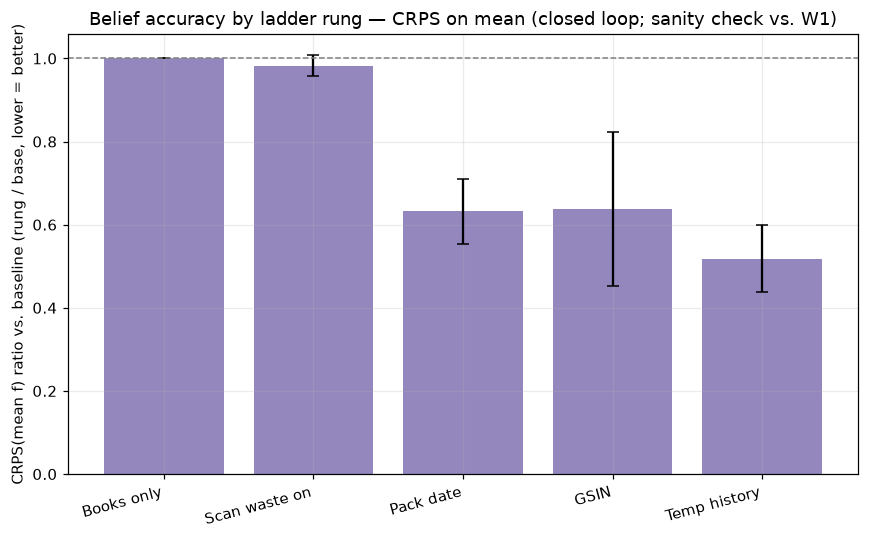

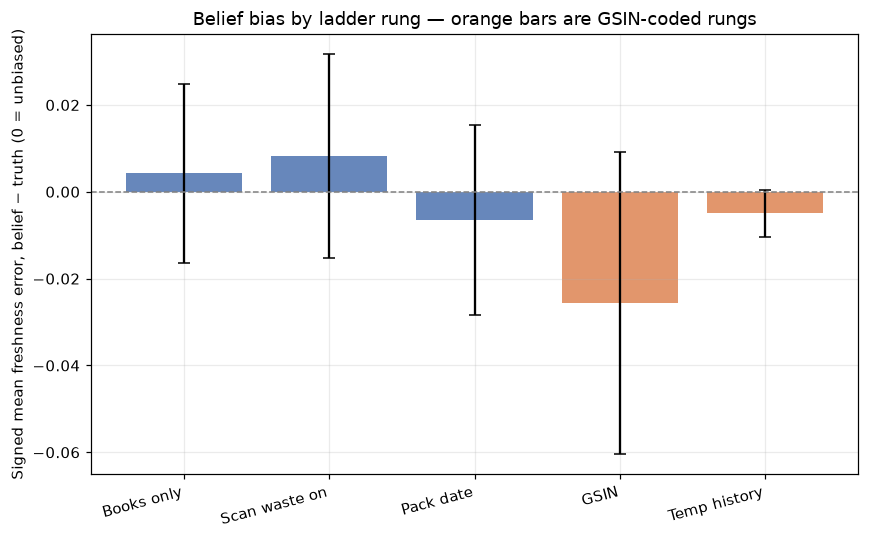

In [10]:
piv_crps = appendix_df.pivot_table(index="seed", columns="rung", values="crps_mean_f")[LADDER_ORDER]
crps_ratio = piv_crps.div(piv_crps["Books only"], axis=0)
crps_mean, crps_ci = mean_ci(crps_ratio)

bar_chart(crps_mean, crps_ci, PURPLE,
          "CRPS(mean f) ratio vs. baseline (rung / base, lower = better)",
          "Belief accuracy by ladder rung — CRPS on mean (closed loop; sanity check vs. W1)",
          "appendix_crps_mean_ratio.png")

piv_bias = appendix_df.pivot_table(index="seed", columns="rung", values="mean_f_error")[LADDER_ORDER]
combos_bias = {label: ch["code_type"] for label, ch in LADDER}
bias_mean = piv_bias.mean()
bias_sem = piv_bias.std(ddof=1) / np.sqrt(len(piv_bias))
colors_bias = [ORANGE if combos_bias[l] == "gsin" else BLUE for l in LADDER_ORDER]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(LADDER_ORDER))
ax.bar(x, bias_mean[LADDER_ORDER], yerr=1.96 * bias_sem[LADDER_ORDER], capsize=4, color=colors_bias, alpha=0.85)
ax.axhline(0.0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(LADDER_ORDER, rotation=15, ha="right")
ax.set_ylabel("Signed mean freshness error, belief − truth (0 = unbiased)")
ax.set_title("Belief bias by ladder rung — orange bars are GSIN-coded rungs")
fig.tight_layout()
fig.savefig(FIG_DIR / "appendix_signed_bias.png", dpi=150)
plt.show()


**Read on the bias chart:** GSIN-coded rungs (orange) cluster at a consistent positive
bias (belief overestimates freshness); UPC-coded rungs (blue) sit close to zero.
Flagged as a real, reproducible pattern worth investigating further — not resolved
here, not currently claimed in the post.

## Can you do better?

No new figure here — the reader-facing challenge harness lives in
[`notebooks/19_build_your_own_controller.ipynb`](19_build_your_own_controller.ipynb),
kept as its own dedicated notebook and linked directly from the post.